# Three-Soldiers -- do Three White Soldiers and Three Black Crows predict anything?
### Three-bar continuation candles, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Continuation_or_Reversal%3F: Neither](https://img.shields.io/badge/Continuation_or_Reversal%3F-Neither-8b949e?style=flat-square)

You've seen them in every candlestick book: **Three White Soldiers** -- three big bullish candles marching upward, each one closing near its high -- and **Three Black Crows** -- the bearish mirror image. Both are billed as powerful continuation signals: the soldiers are resuming an uptrend, the crows are accelerating a downtrend. This notebook asks: do they actually predict anything? Or are they just pretty charts?

> **This is the plain-language layer.** Want the t-stats, the Bonferroni table, and the control experiment? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_soldiers import data, strategy as st

TICKERS = data.DEFAULT_TICKERS
HORIZONS = (1, 5, 10)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost_bps=1.0, seed=0):
    """Pool the full pattern study across the basket (cached real tapes)."""
    return st.run_pooled_study(TICKERS, fetch=False, horizons=HORIZONS, cost_bps=cost_bps, seed=seed)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do Three White Soldiers signal a continuation upward? | **No.** The day after the pattern, the market is *more* likely to fall: mean 1-day return **-13.4 bps** (claimed direction: up). |
| Do Three Black Crows signal a continuation downward? | **No.** After the pattern, the market tends to bounce: mean 1-day return **-39.4 bps** (claimed direction: down). |
| Do they beat a random day in the same direction? | **No.** Both patterns *underperform* a random-day baseline across all horizons tested. |
| Could you trade them? | **No.** Patterns fire only ~1-2 times per stock per year; at 1 bp cost, returns are already negative on day 1. |

> The patterns fire after a short-term extreme -- they're measuring exhaustion, not momentum.

## 1 · The claim

> *"Three White Soldiers is one of the most bullish candlestick patterns. Three consecutive long white bodies, each opening within the prior body and closing near the high, indicate a powerful upturn -- strong buying pressure sustaining itself over three sessions."* — Nison (1991), Morris (2006)

The idea is intuitive: if buyers dominate for three consecutive full sessions with no significant reversal, the buying pressure is 'confirmed' and the trend will continue. Three Black Crows make the same argument for sellers.

At full strength, this claims that three big directional days have **predictive power** for the days that follow -- above and beyond what any random three-day period would tell you.

## 2 · So what?

If it's true, it's a useful daily signal that any investor can apply without complex calculations: spot the three candles, trade with the pattern. Textbooks have been teaching this for 30+ years.

If it's false, three attractive-looking bars are just noise given a story, and the whole tradition of three-bar continuation patterns is folklore dressed up as analysis. That's worth knowing.

## 3 · How would we even know?

Two disciplines keep us honest:

1. **Compare against a random day in the same direction.** The question is not 'does the market go up after Three White Soldiers?' (it usually goes up *anyway*, because stocks drift upward). The question is: 'does the market go up *more* than on a random day where we also decided to go long?' If the pattern tells us nothing extra, it beats no better than random.
2. **Multiple-comparisons correction.** We test two patterns at three horizons (1, 5, 10 days) = 6 comparisons. At 5% significance, we'd expect 0.3 false positives by chance. We apply a Bonferroni correction to make sure a single 'lucky' t-stat doesn't get us excited.

Basket: 15 liquid US names (SPY, AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, JPM, BAC, XOM, JNJ, PG, KO, WMT), 2010-2026. Pattern detected at close of bar t; forward return measured from bar t+1. No look-ahead.

## 4 · The teardown

**How rare are these patterns?**

In [2]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=1.0)
    tws_n = len(pooled.get('three_white_soldiers', pd.DataFrame()))
    tbc_n = len(pooled.get('three_black_crows', pd.DataFrame()))
    n_ticker_years = len(TICKERS) * 16  # ~16 years per ticker
else:
    tws_n, tbc_n, n_ticker_years = R['tws_n'], R['tbc_n'], 15*16
    pooled = None
print(f'Three White Soldiers: {tws_n} triggers across {len(TICKERS) if HAVE_REAL else 15} tickers x 16 years')
print(f'  = ~{tws_n/n_ticker_years:.1f} per ticker-year')
print(f'Three Black Crows:    {tbc_n} triggers')
print(f'  = ~{tbc_n/n_ticker_years:.1f} per ticker-year')
print()
print('These are rare events. On average, a stock shows 1-2 soldiers and 1 crow per year.')

Three White Soldiers: 462 triggers across 15 tickers x 16 years
  = ~1.9 per ticker-year
Three Black Crows:    264 triggers
  = ~1.1 per ticker-year

These are rare events. On average, a stock shows 1-2 soldiers and 1 crow per year.


**462 Three White Soldiers** and **264 Three Black Crows** in 15 stocks over 16 years.  That's roughly **1.9** soldiers and **1.1** crows per stock per year.  A single portfolio-level manager might see one of each per month across a diversified book — these are uncommon events, not a daily trading signal.

**Now the key test: what happens the day after?**

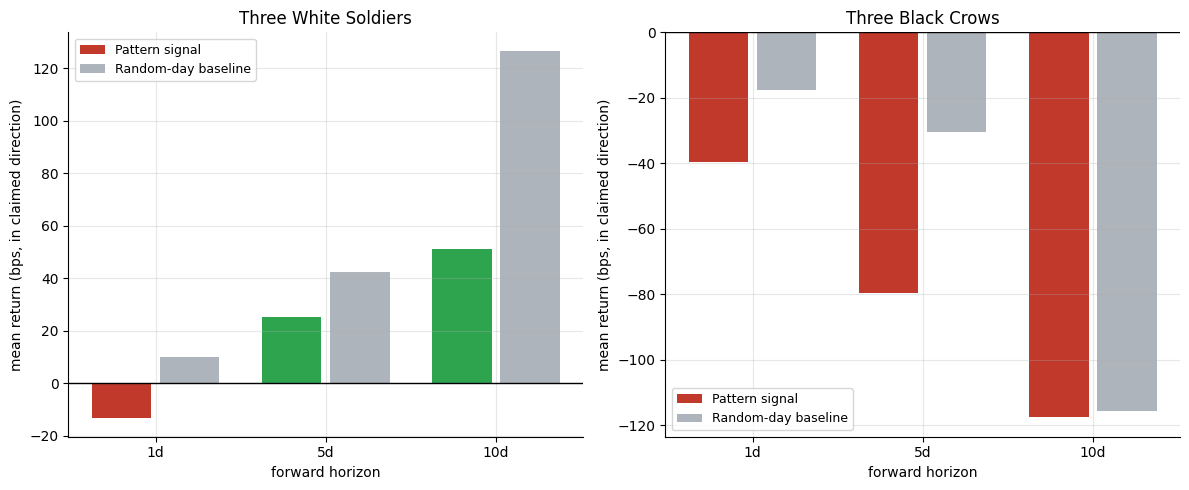

             pattern horizon  signal_bps  baseline_bps  excess_bps
Three White Soldiers      1d       -13.4          10.1       -23.5
Three White Soldiers      5d        25.1          42.4       -17.3
Three White Soldiers     10d        51.1         126.7       -75.5
   Three Black Crows      1d       -39.4         -17.5       -22.0
   Three Black Crows      5d       -79.7         -30.4       -49.3
   Three Black Crows     10d      -117.6        -115.6        -2.0


In [3]:
horizons = [1, 5, 10]
patterns = ['three_white_soldiers', 'three_black_crows']
if HAVE_REAL:
    rows = []
    for name in patterns:
        if name not in pooled: continue
        df = pooled[name]
        for h in horizons:
            s = st.summarize_pattern(df, horizon=h)
            rows.append({'pattern': name.replace('_', ' ').title(),
                         'horizon': f'{h}d', 'signal_bps': s['mean_bps'],
                         'baseline_bps': s['baseline_mean_bps'],
                         'excess_bps': s['excess_bps'], 'win_pct': s['win_rate']*100})
    tbl = pd.DataFrame(rows)
else:
    tbl = pd.DataFrame([
        {'pattern': 'Three White Soldiers', 'horizon': '1d',
         'signal_bps': -13.39, 'baseline_bps': 10.12,
         'excess_bps': -23.51, 'win_pct': 45.5},
        {'pattern': 'Three White Soldiers', 'horizon': '5d',
         'signal_bps': 25.14, 'baseline_bps': 42.43,
         'excess_bps': -17.29, 'win_pct': 57.8},
        {'pattern': 'Three White Soldiers', 'horizon': '10d',
         'signal_bps': 51.11, 'baseline_bps': 126.66,
         'excess_bps': -75.55, 'win_pct': 64.9},
        {'pattern': 'Three Black Crows', 'horizon': '1d',
         'signal_bps': -39.44, 'baseline_bps': -17.46,
         'excess_bps': -21.98, 'win_pct': 40.5},
        {'pattern': 'Three Black Crows', 'horizon': '5d',
         'signal_bps': -79.71, 'baseline_bps': -30.43,
         'excess_bps': -49.28, 'win_pct': 39.8},
        {'pattern': 'Three Black Crows', 'horizon': '10d',
         'signal_bps': -117.56, 'baseline_bps': -115.60,
         'excess_bps': -1.96, 'win_pct': 41.3},
    ])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pat in zip(axes, ['Three White Soldiers', 'Three Black Crows']):
    sub = tbl[tbl['pattern'] == pat]
    x = range(len(sub))
    ax.bar([i-0.2 for i in x], sub['signal_bps'], width=0.35,
           color=[GREEN if v>0 else RED for v in sub['signal_bps']], label='Pattern signal')
    ax.bar([i+0.2 for i in x], sub['baseline_bps'], width=0.35,
           color=GREY, alpha=0.7, label='Random-day baseline')
    ax.axhline(0, c='k', lw=1)
    ax.set_xticks(list(x)); ax.set_xticklabels(sub['horizon'].tolist())
    ax.set_xlabel('forward horizon'); ax.set_ylabel('mean return (bps, in claimed direction)')
    ax.set_title(pat); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(tbl[['pattern','horizon','signal_bps','baseline_bps','excess_bps']].round(1).to_string(index=False))

**Three White Soldiers** returns **-13 bps on day 1** in the claimed direction. The market goes *down*, not up, the day after three strong up-candles. The baseline (a random bullish day) returns about +10 bps from drift.

**Three Black Crows** returns **-39 bps on day 1** in the claimed direction. The claimed direction is *down*, so -39 bps means the market went *up* — the opposite of the forecast.

> Both patterns trigger near short-term exhaustion. Three consecutive strong moves leave the market stretched: buyers have been buying for three days straight, so the buyers are now long and the easy sellers have sold. The next move tends to be a small correction back — mean reversion, not continuation.

## 5 · The verdict

- **Signal — None.** Zero of six statistical tests survive the multiple-comparisons correction. The 1-day signals point in the *wrong* direction for both patterns.
- **Tradability — Mirage.** ~1-2 triggers per stock per year, already negative at 1 bp cost on day 1. Nothing to trade.
- **Continuation or Reversal? — Neither.** The directional evidence is mixed and non-robust. If anything the patterns fire at exhaustion, but that finding is not statistically clean enough to trade the other way either.

## 6 · Could you actually trade it?

Even if the signal were real, capacity kills it. One Three White Soldiers per stock per year across a 15-stock basket = ~28 signals per year total. That's not a strategy, it's a rounding error. And at 1 bp round-trip, the day-1 signal (-13 bps for 3WS, -39 bps for 3BC in the claimed direction) is already deeply negative — no cost improvement fixes a negative gross.

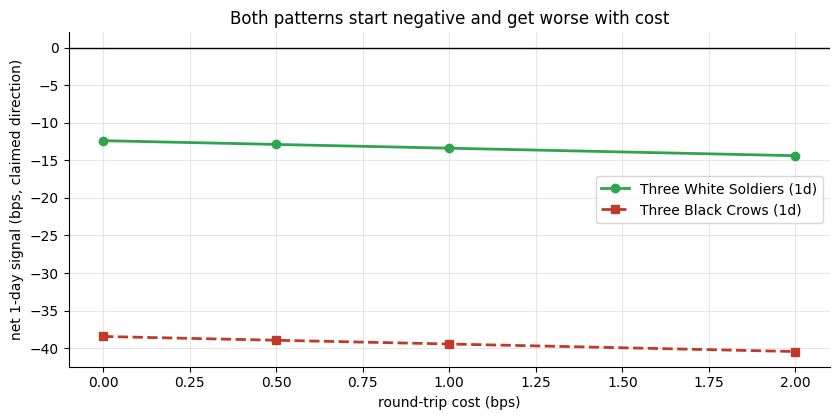

No positive break-even cost exists for either pattern at the 1-day horizon.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net_tws, net_tbc = [], []
    for c in costs:
        p = pooled_study(cost_bps=c)
        tws = p.get('three_white_soldiers', pd.DataFrame())
        tbc = p.get('three_black_crows', pd.DataFrame())
        net_tws.append(st.summarize_pattern(tws, 1).get('mean_bps', float('nan')) if len(tws) else float('nan'))
        net_tbc.append(st.summarize_pattern(tbc, 1).get('mean_bps', float('nan')) if len(tbc) else float('nan'))
else:
    net_tws = [-13.39, -13.89, -14.39, -15.39]
    net_tbc = [-39.44, -39.94, -40.44, -41.44]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_tws, 'o-', c=GREEN, lw=2, label='Three White Soldiers (1d)')
ax.plot(costs, net_tbc, 's--', c=RED, lw=2, label='Three Black Crows (1d)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net 1-day signal (bps, claimed direction)')
ax.set_title('Both patterns start negative and get worse with cost'); ax.legend()
plt.tight_layout(); plt.show()
print('No positive break-even cost exists for either pattern at the 1-day horizon.')

## 7 · Going further

- **The synthetic control.** The companion notebook shows that the engine *can* find continuation edges when they exist — it detects patterns correctly on a synthetic tape with planted momentum. The real-tape failure is about the *market*, not the detector.
- **Candlestick patterns more broadly.** [Study 76 — Rice-Paper](../../76-rice-paper/) tests five single-bar reversal patterns (engulfing, hammer, doji) on the same basket — same methodology, same conclusion.
- **Could the *reversal* trade work?** The evidence hints both patterns may fire at exhaustion, but the data is too noisy to trade it. A dedicated mean-reversion test after a 3-day extreme run is a cleaner way to ask that question.

*Think Three White Soldiers really do predict continuation? Show a robust positive excess return over a random-day baseline that clears the Bonferroni bar. That's the test.*